In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

wine_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(wine_url, sep=';')

## Exploration des données

In [2]:
print(wine.head())

print("Infos :")
print(wine.info())

print("Description :")
print(wine.describe())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [3]:
def analyse_missing_data(df):
    missing = df.isnull().sum()
    missing_pct = 100 * missing / len(df)

    missing_table = pd.DataFrame({
        "Colonnes": missing.index,
        "Valeurs manquantes": missing.values,
        "Pourcentage": missing_pct.values
    })

    missing_table = missing_table[missing_table["Valeurs manquantes"] > 0].sort_values("Pourcentage", ascending=False)

    return missing_table

missing_data = analyse_missing_data(wine)
missing_data

,Colonnes,Valeurs manquantes,Pourcentage


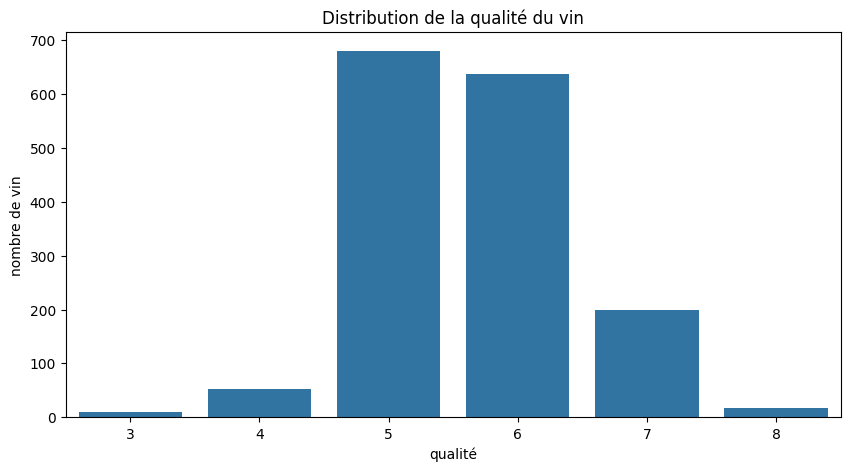

In [4]:
plt.figure(figsize=(10, 5))
sns.countplot(data=wine, x="quality")
plt.title("Distribution de la qualité du vin")
plt.xlabel("qualité")
plt.ylabel("nombre de vin")

plt.show()

In [6]:
wine["good_quality"] = (wine["quality"] >= 6).astype(int)

print(wine["good_quality"].value_counts())

X = wine.drop(["good_quality", "quality"], axis=1)
y = wine["good_quality"]

good_quality
1    855
0    744
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)

accuracy_test = accuracy_score(y_test, y_pred_test)
print(accuracy_test)

accuracy_train = accuracy_score(y_train, y_pred_train)
print(accuracy_train)

0.740625
0.7427677873338546
